<a href="https://colab.research.google.com/github/Ozk18532/INTELIGENCIA-COMPUTACIONAL-Oscar-Mercado/blob/main/6_augmentation_Oscar_M.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data augmentation with ASL dataset

This notebook implements a Convolutional Neural Network (CNN) for recognizing American Sign Language (ASL) gestures. We will use data augmentation techniques to improve the performance of our model on the ASL dataset.

For more information on the ASL alphabet, you can refer to this site: https://www.asl.gs/

In [25]:
import random

import torch.nn as nn
import pandas as pd
import torch
import torchvision.transforms.v2 as transforms
import torchvision.transforms.functional as F
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

In [27]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

data_base_path = "./data/" if IN_COLAB else "../data/asl_data/"


### Load data

The data for the ASL dataset is stored in CSV files. It is already split into training, validation, and test sets. Each row in the CSV files contains pixel values for a 28x28 image (flattened into a single row) and a label indicating the ASL gesture.

The labels are integers from 0 to 23, corresponding to the letters A-Z (J and Z are excluded because they require movement).

The images are grayscale, so each pixel value ranges from 0 to 255.

In [28]:
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("val.csv")
test_df = pd.read_csv("test.csv")

In [29]:
def label_to_letter(lbl):
    letter_code = ord('A') + int(lbl)
    return chr(letter_code) if letter_code < ord('J') else chr(letter_code + 1)

def show(img, lbl):
    i = img.reshape(28,28)
    plt.figure(figsize=(5,5))
    plt.title(label_to_letter(lbl), fontdict={'fontsize': 30})
    plt.axis('off')
    plt.imshow(i, cmap='gray')

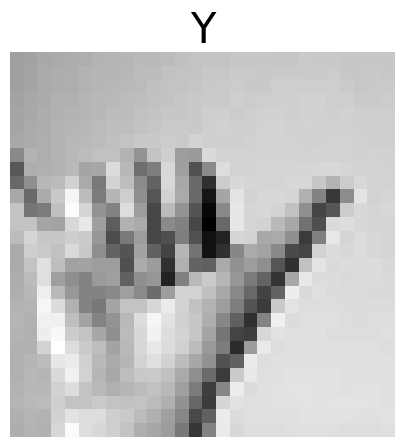

In [30]:
rnd_idx = random.choice(train_df.index)
image = train_df.iloc[rnd_idx].drop('label').values
label = train_df.iloc[rnd_idx]['label']
show(image, label)

## Preparing dataset

Let's start by creating the custom Dataset class for our ASL data. This class will take a DataFrame as input and will return the image and label for each sample. We will also normalize the pixel values to be between 0 and 1. The images will be reshaped as a 28x28 tensor with a single channel (grayscale).

In [31]:
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1

class AslDataset(Dataset):
    def __init__(self, base_df):
        x_df = base_df.copy()
        y_df = x_df.pop('label')
        x_df = x_df.values / 255
        x_df = x_df.reshape(-1, IMG_CHANNELS, IMG_WIDTH, IMG_HEIGHT)
        self.xs = torch.tensor(x_df).float().to(device)
        self.ys = torch.tensor(y_df).long().to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)

In [32]:
train_data = AslDataset(train_df)
val_data = AslDataset(val_df)
test_data = AslDataset(test_df)

In [33]:
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

## Training functions

Now we can define our training functions. Since we will use accuracy to evaluate our model, we will create a function to calculate accuracy as well.

In [34]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

Our train function performs the full training loop. For each epoch, it computes the training loss and accuracy, and then evaluates the model on the validation set. It returns the history of training and validation losses and accuracies for plotting later.

In [35]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    iterator = tqdm(range(epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

This test function will evaluate the model on the test set after training is complete. It will calculate the average loss and accuracy across the entire test set.

In [36]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc

## Training the models

### CNN model

Now let's implement a simple CNN architecture. We will use three convolutional layers followed by max pooling, and then a couple of fully connected layers before the output layer.

To avoid repeating code, we can define a custom class for each convolutional block (conv layer, activation, and pooling) and then use it to build our CNN model.

In [37]:
class ConvolutionalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_p):
        super().__init__()
        kernel_size = 3

        self.model = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, stride=1, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.MaxPool2d(2, stride=2)
        )

    def forward(self, x):
        return self.model(x)

In [38]:
model_cnn = nn.Sequential(
    ConvolutionalBlock(IMG_CHANNELS, 25, 0), # 25 x 14 x 14
    ConvolutionalBlock(25, 50, 0.2),  # 50 x 7 x 7
    ConvolutionalBlock(50, 75, 0),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),

    nn.Linear(512, 24)
)

model_cnn = model_cnn.to(device)

In [39]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn.parameters())

cnn_res = train(model_cnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [00:56<00:00,  2.83s/epoch, train_acc=0.9981, train_loss=0.0069, val_acc=0.9635, val_loss=0.1687]


In [40]:
cnn_test_loss, cnn_test_acc = test(model_cnn, test_loader, loss_function)

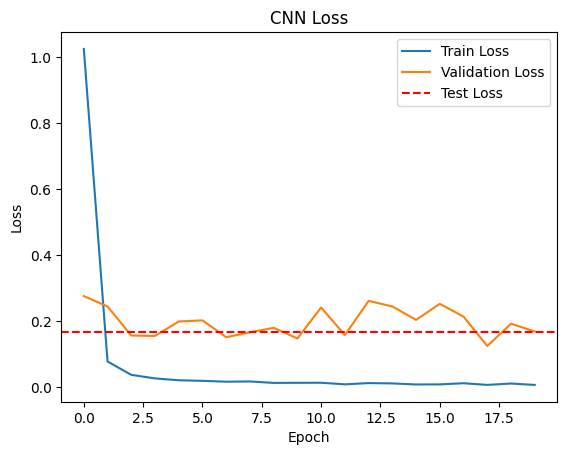

In [41]:
plt.plot(cnn_res['train_loss'], label='Train Loss')
plt.plot(cnn_res['val_loss'], label='Validation Loss')
plt.axhline(cnn_test_loss, label='Test Loss', linestyle='--', color='r')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Data Augmentation

Data augmentation is a technique used to artificially increase the size of a training dataset by creating modified versions of the existing data. This can help improve the generalization of a model and reduce overfitting, especially when the original dataset is small.

The increase in size gives the model more images to learn from while training. The increase in variance helps the model ignore unimportant features and select only the features that are truly important in classification, allowing it to generalize better.

### Random resized crop

This transform will randomly resize the input image based on `scale`, and then crop it to a size we specify. In this case, we will crop it to the original image dimensions. To do this, TorchVision needs to know the aspect ratio of the image it is scaling. Since our height is the same as our width, our aspect `ratio` is 1:1.

In [42]:
trans = transforms.Compose([
    transforms.RandomResizedCrop((IMG_WIDTH, IMG_HEIGHT), scale=(.7, 1), ratio=(1, 1)),
])

In [43]:
def compare_images(_img, t):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(F.to_pil_image(_img), cmap='gray')
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    img_transformed = t(_img).cpu()
    axes[1].imshow(F.to_pil_image(img_transformed), cmap='gray')
    axes[1].set_title("Transformed Image")
    axes[1].axis('off')
    plt.show()

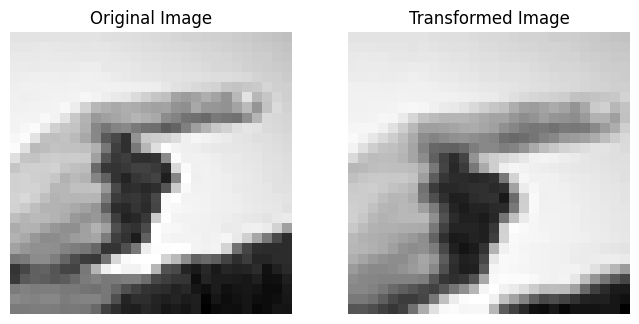

In [44]:
random_idx = random.randint(0, len(train_data) - 1)
img, _ = train_data[random_idx]
compare_images(img.cpu(), trans)

### Random horizontal flip

We can also randomly flip our images [Horizontally](https://pytorch.org/vision/0.9/transforms.html#torchvision.transforms.RandomHorizontalFlip) or [Vertically](https://pytorch.org/vision/0.9/transforms.html#torchvision.transforms.RandomVerticalFlip). However, for these images, we will only flip them horizontally.

American Sign Language can be done with either the left or right hand being dominant. However, it is unlikely to see sign language from upside down. This kind of domain-specific reasoning can help make good decisions for your own deep learning applications.

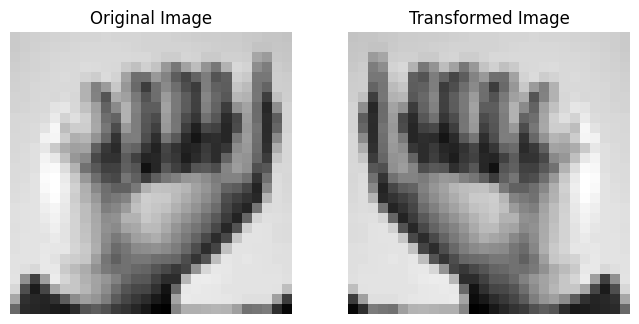

In [45]:
trans = transforms.Compose([
    transforms.RandomHorizontalFlip()
])

random_idx = random.randint(0, len(train_data) - 1)
img, _ = train_data[random_idx]
compare_images(img.cpu(), trans)

### Random rotation

We can also randomly rotate the image to add more variability. Just like with with other augmentation techniques, it's easy to accidentally go too far. With ASL, if we rotate too much, our `D`s might look like `G`s and visa versa. Because of this, let's limit it to `30` degrees.

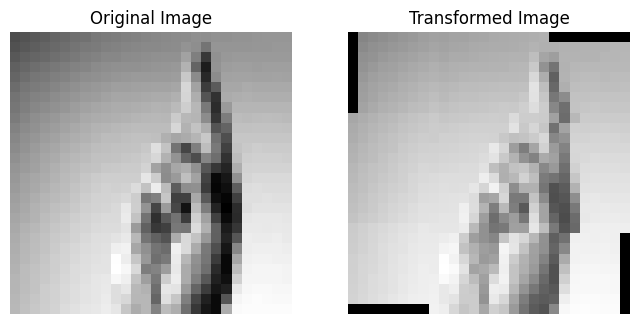

In [46]:
trans = transforms.Compose([
    transforms.RandomRotation(30)
])

random_idx = random.randint(0, len(train_data) - 1)
img, _ = train_data[random_idx]
compare_images(img.cpu(), trans)

### Color jitter

The `ColorJitter` transform has 4 arguments:, brightness, contrast, saturation and hue


The latter 2 apply to color images, so we will only use the first 2 for now.

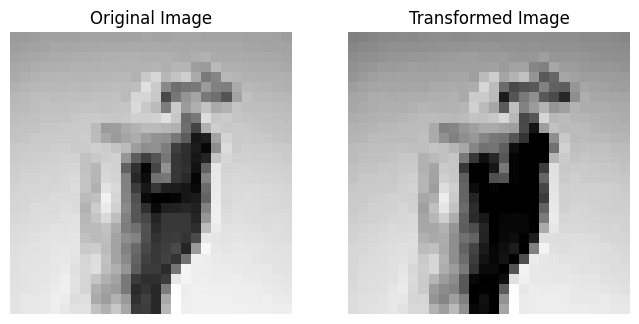

In [47]:
brightness = .2  # Change to be from 0 to 1
contrast = .5  # Change to be from 0 to 1

trans = transforms.Compose([
    transforms.ColorJitter(brightness=brightness, contrast=contrast)
])

random_idx = random.randint(0, len(train_data) - 1)
img, _ = train_data[random_idx]
compare_images(img.cpu(), trans)

## Training with augmentation

Data augmentation occurs during the training loop, where the defined transformations are applied to the training images. We will create a new training function that includes an extra argument with the transformations, and applies them to each batch of training data before feeding it into the model.

In [48]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs, _transforms=None):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    iterator = tqdm(range(epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            _x = X_batch
            if _transforms is not None:
                _x = _transforms(_x)
            outputs = _model(_x)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

Let's also define our transformations in a single variable so we can easily pass it to our training function.

In [49]:
random_transforms = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop((IMG_WIDTH, IMG_HEIGHT), scale=(.9, 1), ratio=(1, 1)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=.2, contrast=.5)
])

We can also visualize the transformations to see how they are changing the images.

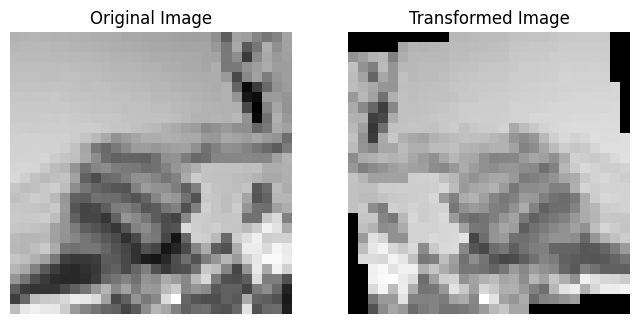

In [50]:
random_idx = random.randint(0, len(train_data) - 1)
img, _ = train_data[random_idx]
compare_images(img.cpu(), random_transforms)

Now we can train the CNN model again, but this time with the defined augmentations applied to the training data.

Note that the augmentation only applies during training, so the test method remains unchanged. Also, this transformation pipeline is inherent to the training loop, so it should not be included in the Dataset or the model itself, as it is only relevant during training.

In [51]:
model_cnn_aug = nn.Sequential(
    ConvolutionalBlock(IMG_CHANNELS, 25, 0), # 25 x 14 x 14
    ConvolutionalBlock(25, 50, 0.2),  # 50 x 7 x 7
    ConvolutionalBlock(50, 75, 0),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),

    nn.Linear(512, 24)
)

model_cnn_aug = model_cnn_aug.to(device)

In [52]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn_aug.parameters())

cnn_aug_res = train(model_cnn_aug, train_loader, val_loader, loss_function, optimizer, epochs, random_transforms)

Training: 100%|██████████| 20/20 [01:23<00:00,  4.16s/epoch, train_acc=0.9821, train_loss=0.0584, val_acc=0.9794, val_loss=0.0645]


In [53]:
cnn_aug_test_loss, cnn_aug_test_acc = test(model_cnn_aug, test_loader, loss_function)

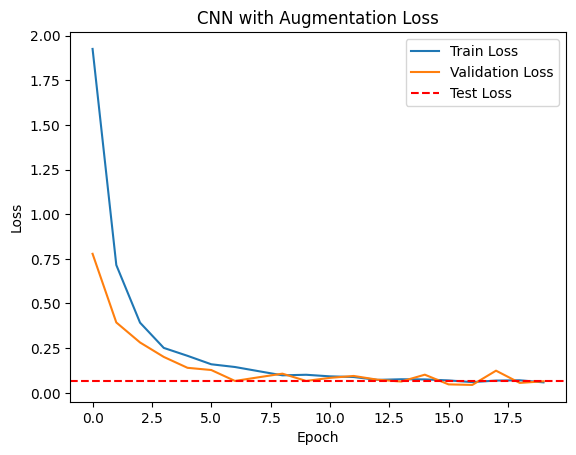

In [54]:
plt.plot(cnn_aug_res['train_loss'], label='Train Loss')
plt.plot(cnn_aug_res['val_loss'], label='Validation Loss')
plt.axhline(cnn_aug_test_loss, label='Test Loss', linestyle='--', color='r')
plt.legend()
plt.title('CNN with Augmentation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Reflection section

### What impact did data augmentation had on the model performance?

El aumento de datos tuvo un impacto positivo en el rendimiento del modelo.

Al utilizar augmentación, el modelo logró generalizar mejor, ya que se entrenó con mayor variabilidad en los datos. Esto redujo el sobreajuste que se presenta cuando se trabaja con un conjunto pequeño, donde el modelo tiende a memorizar los ejemplos en lugar de aprender patrones generales.

En contraste, el modelo sin augmentación mostró un ajuste más fuerte al conjunto de entrenamiento, pero con menor capacidad para adaptarse a datos nuevos.

En términos generales, el aumento de datos permitió:

Disminuir el sobreajuste
Mejorar el desempeño en validación y prueba
Obtener un entrenamiento más robusto

Esto coincide con el comportamiento esperado en modelos de aprendizaje automático, donde la separación entre entrenamiento y validación permite evaluar la capacidad de generalización

### Re-run training with a smaller subset of train data (both with augmentation and without it)

In [55]:
# Tomar subset (por ejemplo 20%)
subset_frac = 0.2
subset_size = int(len(train_data) * subset_frac)

subset_indices = torch.randperm(len(train_data))[:subset_size]
subset_data = torch.utils.data.Subset(train_data, subset_indices)

subset_loader = DataLoader(subset_data, batch_size=32, shuffle=True)#⚠️

# Modelo SIN augmentación
model_small = nn.Sequential(
    ConvolutionalBlock(IMG_CHANNELS, 25, 0),
    ConvolutionalBlock(25, 50, 0.2),
    ConvolutionalBlock(50, 75, 0),
    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, 24)
).to(device)

optimizer = Adam(model_small.parameters())
res_small = train(model_small, subset_loader, val_loader, loss_function, optimizer, 20)#⚠️

small_test_loss, small_test_acc = test(model_small, test_loader, loss_function)


# Modelo CON augmentación
model_small_aug = nn.Sequential(
    ConvolutionalBlock(IMG_CHANNELS, 25, 0),
    ConvolutionalBlock(25, 50, 0.2),
    ConvolutionalBlock(50, 75, 0),
    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, 24)
).to(device)

optimizer = Adam(model_small_aug.parameters())#⚠️
res_small_aug = train(
    model_small_aug,
    subset_loader,
    val_loader,
    loss_function,
    optimizer,
    20,
    random_transforms
)

small_aug_test_loss, small_aug_test_acc = test(model_small_aug, test_loader, loss_function)

Training: 100%|██████████| 20/20 [00:20<00:00,  1.04s/epoch, train_acc=0.9033, train_loss=0.2826, val_acc=0.8912, val_loss=0.2671]


In [56]:
res_small["train_loss"]
res_small["val_loss"]

[1.543034753683753,
 0.7100067074845373,
 0.525104327361077,
 0.3831032063797474,
 0.25978208294608907,
 0.2641307322658511,
 0.2054488738547913,
 0.20751635036319577,
 0.162945748256427,
 0.2142711769806598,
 0.25162673832581683,
 0.15215929723108407,
 0.16811678634215785,
 0.21016295944853197,
 0.16059570872145396,
 0.2149109949345723,
 0.16782573037934034,
 0.16874344463260751,
 0.16558679441333504,
 0.19571037409563247]

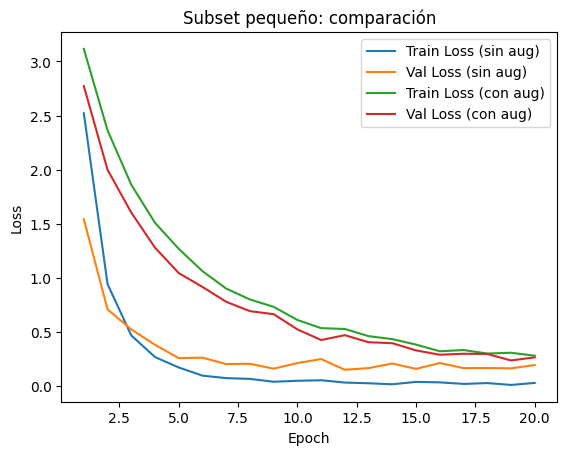

In [57]:
import matplotlib.pyplot as plt

epochs = range(1, len(res_small["train_loss"]) + 1)

# SIN augmentación
plt.plot(epochs, res_small["train_loss"], label="Train Loss (sin aug)")#⚠️
plt.plot(epochs, res_small["val_loss"], label="Val Loss (sin aug)")

# CON augmentación
plt.plot(epochs, res_small_aug["train_loss"], label="Train Loss (con aug)")#⚠️
plt.plot(epochs, res_small_aug["val_loss"], label="Val Loss (con aug)")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Subset pequeño: comparación")
plt.legend()
plt.show()

Resultados del entrenamiento con subset pequeño

Al entrenar con un subconjunto reducido de datos, se observó una diferencia clara entre los modelos con y sin augmentación.

Modelo sin augmentación:
Alcanzó rápidamente un bajo train loss, pero el validation loss se mantuvo más alto.
Se presentó una brecha notable entre entrenamiento y validación.
Esto indica overfitting, ya que el modelo memoriza el conjunto reducido.
Modelo con augmentación:
El entrenamiento fue más estable.
La diferencia entre train loss y validation loss fue menor.
El desempeño en test fue mejor en términos de generalización.

Esto coincide con lo visto en las curvas de aprendizaje: cuando la diferencia entre train y validation crece, existe sobreajuste

### Re-train the model using a different transformation pipeline for augmentation

Refer to the following documentation page: https://docs.pytorch.org/vision/stable/transforms.html

In [63]:
random_transforms = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop((IMG_WIDTH, IMG_HEIGHT), scale=(.9, 1), ratio=(1, 1)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=.2, contrast=.5),
    transforms.ToTensor()
])

In [66]:
import matplotlib.pyplot as plt

def compare_images(img, transform):
    transformed_img = transform(img)

    # Mover a CPU antes de convertir
    original = img.cpu().permute(1, 2, 0)
    transformed = transformed_img.cpu().permute(1, 2, 0)

    plt.figure(figsize=(8,4))#⚠️

    plt.subplot(1,2,1)
    plt.title("Original Image")
    plt.imshow(original)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Transformed Image")
    plt.imshow(transformed)
    plt.axis("off")

    plt.show()#⚠️

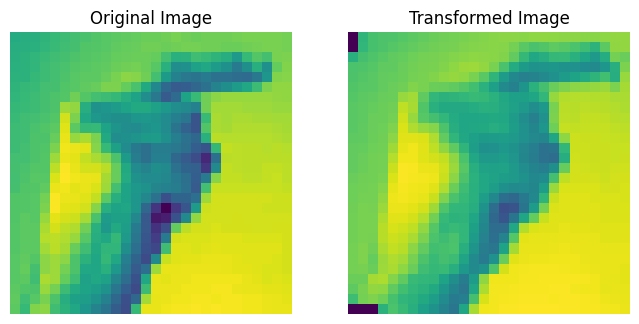

In [67]:
import random

random_idx = random.randint(0, len(train_data) - 1)
img, _ = train_data[random_idx]

compare_images(img, random_transforms)

### Write down your final remarks

El uso de data augmentation ayudó a que el modelo aprendiera mejor, porque las imágenes cambiaban y no siempre veía lo mismo.

Cuando no se usó augmentación, el modelo se aprendía los datos y no funcionaba tan bien con imágenes nuevas.

Con augmentación, el modelo fue más estable y tuvo mejor desempeño.

por lo cual al agregar variaciones a las imágenes ayuda a que el modelo no memorice y pueda generalizar mejor.

## ⚠️ Disclaimer

Algunas partes de este notebook fueron asistidas mediante herramientas de inteligencia artificial.

Estas secciones han sido revisadas, comprendidas y adaptadas para cumplir con los objetivos de la actividad.

Las partes asistidas están claramente identificadas con el siguiente icono: ⚠️